### Split Val and Train

In [9]:
# randomly move 20% of raw_train into raw_val
from pathlib import Path
import shutil
import numpy as np

source = Path("data/raw_train")
destination = Path("data/raw_val")

raw_dir = Path("data/raw_train")
TRAIN_VAL_SPLIT = 0.2 # fraction of training set that goes to validation.

if not any(destination.iterdir()):
    print(f"Validation Directory is Empty, Moving {TRAIN_VAL_SPLIT*100}% of Training Set to Validation Set")
    for txt_path in raw_dir.glob("*.txt"):
        moveToVal = np.random.choice(a=[True, False], p=[TRAIN_VAL_SPLIT, 1-TRAIN_VAL_SPLIT])
        if moveToVal:
            dest = shutil.move(txt_path, destination / txt_path.name)
    print(f"Partition complete.")
else:
    print("Validation Directory Not Empty, Restore Training Set Before Partitioning")

Validation Directory Not Empty, Restore Training Set Before Partitioning


### Processing the Raw Training Set Data

In [10]:
from pathlib import Path
import pandas as pd
from src.gesture_from_path import gesture_from_path

import matplotlib.pyplot as plt
from src.kalman import kalman_filter

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


raw_dir = Path("data/raw_train")

col_names = ["ts", "Wx", "Wy", "Wz", "Ax", "Ay", "Az"]
sensor_cols = ["Wx", "Wy", "Wz", "Ax", "Ay", "Az"]

X_chunks = []
records = []

for txt_path in raw_dir.glob("*.txt"):
    # import raw training data
    raw_gesture = pd.read_csv(txt_path, header=None, sep=r"\s+", engine="python") # used regex to separate cols by any whitespace
    raw_gesture.columns = col_names

    # get gesture type
    gesture_type = gesture_from_path(txt_path)

    # apply 1D kalman filter to each column of IMU data
    ts = raw_gesture["ts"].to_numpy()
    fil_gesture = pd.DataFrame({"ts": ts})
    for col in sensor_cols:
        fil_gesture[col] = kalman_filter(raw_gesture[col].to_numpy(dtype="float64"))

    X = fil_gesture[sensor_cols].to_numpy(dtype=np.float32)
    X_chunks.append(X)

    # make record for final formatting later
    records.append(
        {
            "id": txt_path.stem,
            "gesture": gesture_type,
            "ts": ts,
            "X": X  
        }
    )

X_all = np.vstack(X_chunks) # merge all "per file" data points to one large numpy array

# scale all sensor data
scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

# fit K-means clustering to discretize observation space
num_clusters = 100
kmeans = KMeans(n_clusters=num_clusters, random_state=0, n_init="auto").fit(X_all_scaled)

# format all processed data ready for HMM
processed_dir = Path("data/processed_train")
processed_dir.mkdir(parents=True, exist_ok=True)

for record in records:
    # since we fit k-means onto scaled data, we must scale our data again
    X_scaled = scaler.transform(record["X"])
    O = kmeans.predict(X_scaled) # observations

    out_path = processed_dir / f"{record["id"]}.npz"
    np.savez(
        out_path,
        O = O,
        gesture = record["gesture"],
        ts = record["ts"],
        id = record["id"],
        num_clusters = num_clusters # store the number of clusters
    )

### Processing the Validation Set (Don't Fit KMeans)

In [11]:
from pathlib import Path
import pandas as pd
from src.gesture_from_path import gesture_from_path

import matplotlib.pyplot as plt
from src.kalman import kalman_filter

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


raw_val_dir = Path("data/raw_val")

col_names = ["ts", "Wx", "Wy", "Wz", "Ax", "Ay", "Az"]
sensor_cols = ["Wx", "Wy", "Wz", "Ax", "Ay", "Az"]

X_chunks = []
records = []

for txt_path in raw_val_dir.glob("*.txt"):
    # import raw training data
    raw_gesture = pd.read_csv(txt_path, header=None, sep=r"\s+", engine="python") # used regex to separate cols by any whitespace
    raw_gesture.columns = col_names

    # get gesture type
    gesture_type = gesture_from_path(txt_path)

    # apply 1D kalman filter to each column of IMU data
    ts = raw_gesture["ts"].to_numpy()
    fil_gesture = pd.DataFrame({"ts": ts})
    for col in sensor_cols:
        fil_gesture[col] = kalman_filter(raw_gesture[col].to_numpy(dtype="float64"))

    X = fil_gesture[sensor_cols].to_numpy(dtype=np.float32)
    X_chunks.append(X)

    # make record for final formatting later
    records.append(
        {
            "id": txt_path.stem,
            "gesture": gesture_type,
            "ts": ts,
            "X": X  
        }
    )

X_val = np.vstack(X_chunks) # merge all "per file" data points to one large numpy array

# scale all sensor data (DONT FIT VALIDATION DATA)
X_val_scaled = scaler.transform(X_val)

# kmeans, don't fit just transform
# format all processed data ready for HMM
processed_val_dir = Path("data/processed_val")
processed_val_dir.mkdir(parents=True, exist_ok=True)

for record in records:
    # since we fit k-means onto scaled data, we must scale our data again
    X_scaled = scaler.transform(record["X"])
    O = kmeans.predict(X_scaled) # observations

    out_path = processed_val_dir / f"{record["id"]}.npz"
    np.savez(
        out_path,
        O = O,
        gesture = record["gesture"],
        ts = record["ts"],
        id = record["id"],
        num_clusters = num_clusters # store the number of clusters
    )

### Visualizing and Quantizing One Recording

In [12]:
from scripts.config import (
    RAW_TRAIN_DIR
)
import pandas as pd

# import raw training data
col_names = ["ts", "Wx", "Wy", "Wz", "Ax", "Ay", "Az"]
raw_gesture = pd.read_csv(RAW_TRAIN_DIR / "beat3_01.txt", header=None, sep="\t ", engine="python")
raw_gesture.columns = col_names
raw_gesture.head()

,ts,Wx,Wy,Wz,Ax,Ay,Az
0,1,-0.039505,-0.013031,0.039139,2.169327,7.736588,5.010849
1,8,-0.039505,-0.005020,0.027390,2.121719,7.796097,4.929916
2,12,-0.035233,0.009399,0.022049,2.119339,7.753250,4.968002
3,16,-0.029892,0.032898,0.012436,2.021744,7.691360,5.063217
4,20,-0.022949,0.053192,0.009766,2.021744,7.672318,4.979904


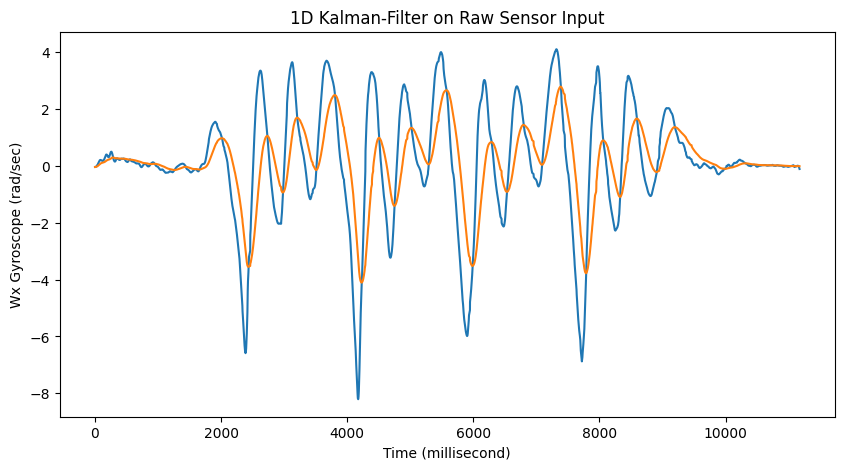

In [13]:
import matplotlib.pyplot as plt

from src.kalman import kalman_filter

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# apply 1D kalman filter to each column of IMU data
fil_gesture = pd.DataFrame(columns = raw_gesture.columns)
for col in fil_gesture.columns:
    if col == "ts":
        fil_gesture[col] = raw_gesture[col] # assume that ts is measured without error for consistency
    else:
        fil_gesture[col] = kalman_filter(raw_gesture[col])

# plot raw vs. smoothed
fig, ax = plt.subplots(1,1,figsize=(10,5))
ax.plot(raw_gesture["ts"], raw_gesture["Wx"], label="Raw IMU Measurement")
ax.plot(fil_gesture["ts"], fil_gesture["Wx"], label="Kalman-Filtered IMU Measurement")
ax.set_xlabel("Time (millisecond)")
ax.set_ylabel("Wx Gyroscope (rad/sec)")
ax.set_title("1D Kalman-Filter on Raw Sensor Input")

plt.savefig("outputs/figures/kalman_filter", bbox_inches='tight')
plt.show()

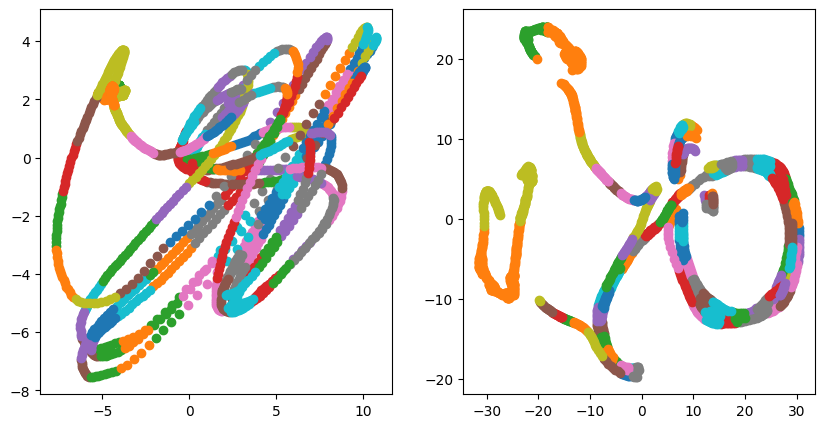

In [17]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

labels = KMeans(n_clusters=100, random_state=0, n_init='auto').fit_predict(fil_gesture.drop(labels="ts", axis=1, inplace=False))
X_decomp = PCA(n_components=2).fit_transform(fil_gesture.drop(labels="ts", axis=1, inplace=False))
X_tsne = TSNE(n_components=2, perplexity=100).fit_transform(fil_gesture.drop(labels="ts", axis=1, inplace=False))

fig, ax = plt.subplots(1,2,figsize=(10,5))

for i in np.unique(labels):
    ax[0].scatter(X_decomp[labels == i, 0], X_decomp[labels == i, 1], label = i)
    ax[1].scatter(X_tsne[labels == i, 0], X_tsne[labels == i, 1], label = i)

plt.show()